In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from scipy.interpolate import make_interp_spline, BSpline

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['text.usetex'] = True
warnings.filterwarnings(action="ignore")

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
df = pd.read_csv('Ratio2.csv')
delta = abs(df['Mn/Mp (FEM)'] - df['Mn/Mp (Formula)'])
threshold = 0.15
df = df[delta < threshold]
df.head()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp (Formula),Mn/Mp (FEM)
0,45.85,41.0,4.49,2.66,1.72,208.28,0.57,0.84,0.96
1,54.44,41.0,4.49,2.66,1.72,208.28,0.78,0.76,0.88
2,65.90,41.0,4.49,2.66,1.72,208.28,1.10,0.65,0.75
3,74.50,41.0,4.49,2.66,1.72,208.28,1.36,0.57,0.62
4,85.96,41.0,4.49,2.66,1.72,208.28,1.74,0.48,0.42


In [3]:
X_full = df[['Lb/ry', 'h/tw', 'B/2t', 'h/B', 'tf/tw', 'E/Fy', 'Mp/Mcr']]
y_full = df['Mn/Mp (FEM)']

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=123)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=123)

In [4]:
# Normalize features using mean and std (PyTorch style)
X_train_mean = X_train.mean()
X_train_std = X_train.std()
X_train_transformed = (X_train - X_train_mean) / X_train_std

X_full_transformed = (X_full - X_train_mean) / X_train_std
X_val_transformed = (X_val - X_train_mean) / X_train_std
X_test_transformed = (X_test - X_train_mean) / X_train_std

In [5]:
X_train_tensor = torch.tensor(X_train_transformed.values, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)

X_test_tensor = torch.tensor(X_test_transformed.values, dtype=torch.float32).to(device)

X_val_tensor = torch.tensor(X_val_transformed.values, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1).to(device)

In [6]:
class MLP(nn.Module):
    def __init__(self, input_dim, layer_size):
        super().__init__()
        layers = []
        for _ in range(7):
            layers.append(nn.Linear(input_dim, layer_size))
            layers.append(nn.ReLU())
            input_dim = layer_size
        layers.append(nn.Linear(layer_size, 1))
        self.model = nn.Sequential(*layers)
    def forward(self, x):
        return self.model(x)

In [ ]:
layersize = list(range(5, 25))
lmselist = []

for x in layersize:
    mse_tests = []
    for _ in tqdm(range(64)):
        model = MLP(X_train_tensor.shape[1], x).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        loss_fn = nn.MSELoss()

        epochs = 500
        best_val_loss = float('inf')
        patience = 10
        best_model_state = None

        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()
            outputs = model(X_train_tensor)
            loss = loss_fn(outputs, y_train_tensor)
            loss.backward()
            optimizer.step()

            model.eval()
            with torch.no_grad():
                val_outputs = model(X_val_tensor)
                val_loss = loss_fn(val_outputs, y_val_tensor)

            if val_loss.item() < best_val_loss:
                best_val_loss = val_loss.item()
                best_model_state = model.state_dict()
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                break
        
        if best_model_state is not None:
            model.load_state_dict(best_model_state)

        model.eval()
        with torch.no_grad():
            ypred = model(X_test_tensor).cpu().numpy()
            test_loss = mean_squared_error(y_test, ypred)
            mse_tests.append(test_loss)

    # Only append if mse_tests is not empty
    if mse_tests:
        lmselist.append(np.mean(mse_tests))
    else:
        lmselist.append(np.nan)

In [ ]:
layersize_new = np.linspace(np.min(layersize), np.max(layersize), 300)
spl = make_interp_spline(layersize, lmselist, k=2)  # type: BSpline
lmselist_new = spl(layersize_new)

plt.figure(figsize=(4, 4))
plt.plot(layersize_new, lmselist_new)
plt.scatter(layersize, lmselist)
plt.ylabel("Mean Squared Error")
plt.xlabel("No of neurons")
plt.savefig(f'MLP/mse-neurons.png', dpi=640, bbox_inches='tight')
# plt.xlim([8, 25])
# plt.ylim([0, 0.001])
plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

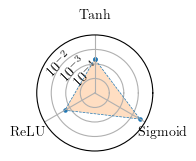

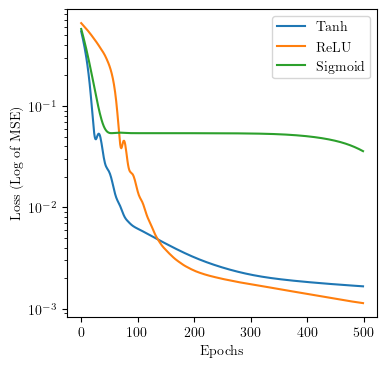

In [24]:
activations = {'tanh': nn.Tanh, 'relu': nn.ReLU, 'logistic': nn.Sigmoid}
mselist = []
loss_curves = []

for af_name, af in activations.items():
    class CustomMLP(nn.Module):
        def __init__(self, input_dim, layer_size, activation):
            super().__init__()
            layers = []
            for _ in range(7):
                layers.append(nn.Linear(input_dim, layer_size))
                layers.append(activation())
                input_dim = layer_size
            layers.append(nn.Linear(layer_size, 1))
            self.model = nn.Sequential(*layers)
        def forward(self, x):
            return self.model(x)

    model = CustomMLP(X_train_tensor.shape[1], 20, af).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    epochs = 500
    losses = []
    for epoch in tqdm(range(epochs)):
        model.train()
        optimizer.zero_grad()
        output = model(X_train_tensor)
        loss = loss_fn(output, y_train_tensor)
        losses.append(loss.item())
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        y_predict = model(X_test_tensor).cpu().numpy().flatten()
        mse_test = mean_squared_error(y_test, y_predict)

    loss_curves.append(losses)
    mselist.append(mse_test)

mselist = np.log10(mselist)
num_vars = len(activations)

# Compute angle for each axis, rotated so first (LBFGS) is on top
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles = [a + np.pi / 2 for a in angles]  # Rotate 90 degrees to start at top
mselist = np.concatenate((mselist, [mselist[0]]))  # Close the loop
angles += angles[:1]

# Create radar chart
fig, ax = plt.subplots(figsize=(2, 2), subplot_kw=dict(polar=True))
ax.scatter(angles, mselist, s=5)
ax.plot(angles, mselist, '--', linewidth=0.5)
ax.fill(angles, mselist, alpha=0.25)

# Customize labels and ticks
ax.set_xticks(angles[:-1])
ax.set_xticklabels(["Tanh", "ReLU", "Sigmoid"])
ax.set_rlabel_position(180)
ax.set_yticks([-4, -3, -2])  # Log10 ticks
ax.yaxis.set_tick_params(rotation=45)
ax.set_rlabel_position(180 - 20)
ax.set_yticklabels(["$10^{-4}$", "$10^{-3}$", "$10^{-2}$"])
ax.set_ylim(-5, -1)

plt.tight_layout()
plt.savefig(f'MLP/mse-activation.png', dpi=640, bbox_inches='tight')
plt.show()

plt.figure(figsize=(4, 4))
for af_name, loss in zip(activations.keys(), loss_curves):
    if af_name == 'tanh':
        label = 'Tanh'
    elif af_name == 'relu':
        label = 'ReLU'
    else:
        label = 'Sigmoid'
    plt.semilogy(range(len(loss)), loss, label=label)
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss (Log of MSE)")
# plt.show()
plt.savefig(f'MLP/loss-activation', dpi=640, bbox_inches='tight')
plt.show()

  0%|          | 0/5000 [00:00<?, ?it/s]

Early stopping triggered with best loss 0.003107977332547307


  0%|          | 0/5000 [00:00<?, ?it/s]

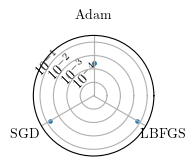

In [22]:
solvers = {'adam': optim.Adam, 'sgd': optim.SGD, 'lbfgs': optim.LBFGS}
mselist = []
r2list = []

for slv_name, slv in solvers.items():
    model = MLP(X_train_tensor.shape[1], 20).to(device)
    if slv_name == 'lbfgs':
        optimizer = slv(model.parameters(), max_iter=5000)

        def closure():
            optimizer.zero_grad()
            output = model(X_train_tensor)
            loss = nn.MSELoss()(output, y_train_tensor)
            loss.backward()
            return loss

        optimizer.step(closure)
    else:
        optimizer = slv(model.parameters(), lr=0.01)
        loss_fn = nn.MSELoss()
        best_model_state = None
        best_val_loss = float('inf')
        patience = 50
        patience_counter = 0

        epochs = 5000
        for epoch in tqdm(range(epochs)):
            model.train()
            optimizer.zero_grad()
            output = model(X_train_tensor)
            loss = loss_fn(output, y_train_tensor)
            loss.backward()
            optimizer.step()

            model.eval()
            with torch.no_grad():
                val_outputs = model(X_val_tensor)
                val_loss = loss_fn(val_outputs, y_val_tensor)

            if val_loss.item() < best_val_loss:
                best_val_loss = val_loss.item()
                best_model_state = model.state_dict()
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print("Early stopping triggered with best loss", best_val_loss)
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    model.eval()
    with torch.no_grad():
        y_predict = model(X_test_tensor).cpu().numpy().flatten()
        mse_test = mean_squared_error(y_test, y_predict)
        r2_test = r2_score(y_test, y_predict)
    mselist.append(mse_test)
    r2list.append(r2_test)

mselist = np.log10(mselist)
num_vars = len(solvers)

# Compute angle for each axis, rotated so first (LBFGS) is on top
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles = [a + np.pi / 2 for a in angles]  # Rotate 90 degrees to start at top
mselist = np.concatenate((mselist, [mselist[0]]))  # Close the loop
angles += angles[:1]

# Create radar chart
fig, ax = plt.subplots(figsize=(2, 2), subplot_kw=dict(polar=True))
ax.scatter(angles, mselist, s=5)
# ax.plot(angles, mselist, '--')
# ax.fill(angles, mselist, alpha=0.25)

# Customize labels and ticks
ax.set_xticks(angles[:-1])
ax.set_xticklabels(["Adam", "SGD", "LBFGS"])
ax.set_rlabel_position(180)
ax.set_yticks([-4, -3, -2, -1])  # Log10 ticks
ax.set_yticklabels(["$10^{-4}$", "$10^{-3}$", "$10^{-2}$", "$10^{-1}$"])
ax.yaxis.set_tick_params(rotation=45)
ax.set_rlabel_position(180 - 20)
ax.set_ylim(-5, -0.5)

plt.tight_layout()
plt.savefig(f'MLP/mse-solver.png', dpi=640, bbox_inches='tight')
plt.show()

In [ ]:
import os

def plot_mlp_accuracy(y_train, y_test, train_pred, test_pred, title="MLP"):
    os.makedirs(title, exist_ok=True)
    # Train R2
    r2_train = r2_score(train_pred, y_train)
    fig_train, ax = plt.subplots(figsize=(4, 4))
    ax.plot([0, 1], [0, 1], 'k--')
    ax.text(0.1, 0.7, f"$R^2={r2_train:.5f}$")
    ax.scatter(y_train, train_pred, c='b', alpha=0.5, label='Train data')
    ax.set_xlabel("Actual Value")
    ax.set_ylabel("Predicted Value")
    ax.legend()
    fig_train.savefig(f"{title}/{title}-train.png", dpi=640, bbox_inches="tight")
    plt.close(fig_train)

    # Test R2
    r2_test = r2_score(test_pred, y_test)
    fig_test, ax = plt.subplots(figsize=(4, 4))
    ax.plot([0, 1], [0, 1], 'k--')
    ax.text(0.1, 0.7, f"$R^2={r2_test:.5f}$")
    ax.scatter(y_test, test_pred, c='r', alpha=0.5, label='Test data')
    ax.set_xlabel("Actual Value")
    ax.set_ylabel("Predicted Value")
    ax.legend()
    fig_test.savefig(f"{title}/{title}-test.png", dpi=640, bbox_inches="tight")
    plt.close(fig_test)

    # Full R2
    y_full = np.concatenate([y_train, y_test])
    full_pred = np.concatenate([train_pred, test_pred])
    r2_full = r2_score(full_pred, y_full)
    fig_full, ax = plt.subplots(figsize=(4, 4))
    ax.plot([0, 1], [0, 1], 'k--')
    ax.text(0.1, 0.7, f"$R^2={r2_full:.5f}$")
    ax.scatter(y_train, train_pred, c='b', alpha=0.5, label='Train data')
    ax.scatter(y_test, test_pred, c='r', alpha=0.5, label='Test data')
    ax.set_xlabel("Actual Value")
    ax.set_ylabel("Predicted Value")
    ax.legend()
    fig_full.savefig(f"{title}/{title}-full.png", dpi=640, bbox_inches="tight")
    plt.close(fig_full)

    print(f"Train R2: {r2_train:.5f}, Test R2: {r2_test:.5f}, Full R2: {r2_full:.5f}")

# Reset X_full and y_full to previous value from the dataframe
X_full = df[['Lb/ry', 'h/tw', 'B/2t', 'h/B', 'tf/tw', 'E/Fy', 'Mp/Mcr']]
y_full = df['Mn/Mp (FEM)']

# Resplit to test and train sets
X_train_full, X_test, y_train_full, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=123)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=123)

# Normalize features
X_train_mean = X_train.mean()
X_train_std = X_train.std()

X_train_transformed = (X_train - X_train_mean) / X_train_std

X_train_full_transformed = (X_train_full - X_train_mean) / X_train_std
X_test_transformed = (X_test - X_train_mean) / X_train_std
X_val_transformed = (X_val - X_train_mean) / X_train_std

X_train_full_tensor = torch.tensor(X_train_full_transformed.values, dtype=torch.float32).to(device)
y_train_full_tensor = torch.tensor(y_train_full.values, dtype=torch.float32).view(-1, 1).to(device)

X_train_tensor = torch.tensor(X_train_transformed.values, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)

X_test_tensor = torch.tensor(X_test_transformed.values, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1).to(device)

X_val_tensor = torch.tensor(X_val_transformed.values, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1).to(device)

# Train PyTorch MLP model
model = MLP(X_train_tensor.shape[1], 20).to(device)
# optimizer = optim.LBFGS(model.parameters(), max_iter=3000)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()
best_model_state = None
best_val_loss = float('inf')
patience = 20
patience_counter = 0

# Loss Curve
train_losses = []
val_losses = []

epochs = 2000
for epoch in tqdm(range(epochs)):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_tensor)
    loss = loss_fn(outputs, y_train_tensor)

    loss.backward()
    optimizer.step()

    # Validation loss for early stopping
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = loss_fn(val_outputs, y_val_tensor)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

plt.figure(figsize=(4, 4))
plt.semilogy(range(len(train_losses)), train_losses, label='Train Loss', color='blue')
plt.semilogy(range(len(val_losses)), val_losses, label='Validation Loss', color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss (Log of MSE)")
plt.legend()
plt.savefig(f'MLP/loss-curve.png', dpi=640, bbox_inches='tight')
plt.show()

# if best_model_state is not None:
#     model.load_state_dict(best_model_state)

model.eval()
with torch.no_grad():
    train_pred = model(X_train_full_tensor).cpu().numpy().flatten()
    test_pred = model(X_test_tensor).cpu().numpy().flatten()

plot_mlp_accuracy(y_train_full.values, y_test.values, train_pred, test_pred, title="MLP")